In [1]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/envs/__init__.py:35: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/benchmarks/__init__.py:26: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


DACBench Gym registration failed - make sure you have all dependencies installed and their instance sets in the right path!


In [2]:
def toDataFrame(glob_path, col_name, col_index):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()
    df['epoch'] = df.index + 1
    df = df.melt(id_vars=['epoch'])

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df

sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
sns.set_palette(palette)

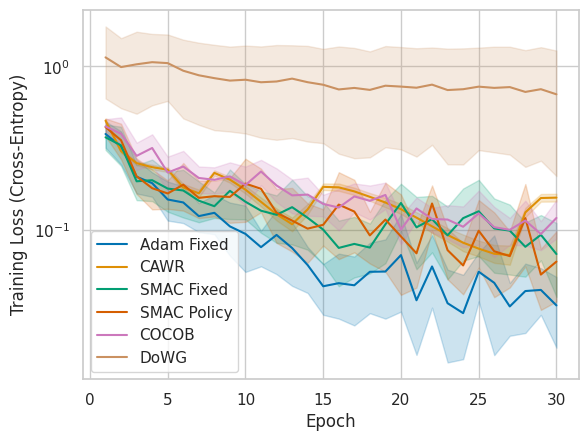

In [3]:

cocob_tl = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
adam_fixed_tl = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
smac_fixed_tl = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
cawr_tl = toChunkedDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, 750)
smac_policy_tl = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
dowg_tl = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)

sns.lineplot(data=adam_fixed_tl, x='epoch', y='value', label='Adam Fixed')
sns.lineplot(data=cawr_tl, x='epoch', y='value', label='CAWR')
sns.lineplot(data=smac_fixed_tl, x='epoch', y='value', label='SMAC Fixed')
sns.lineplot(data=smac_policy_tl, x='epoch', y='value', label='SMAC Policy')
sns.lineplot(data=cocob_tl, x='epoch', y='value', label='COCOB')
sns.lineplot(data=dowg_tl, x='epoch', y='value', label='DoWG')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (Cross-Entropy)')
plt.yscale('log')

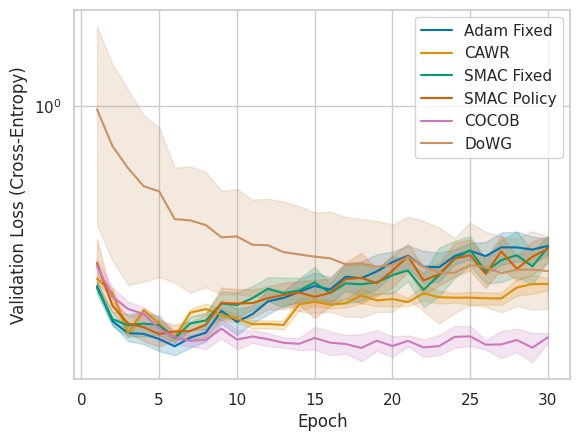

In [5]:

cocob_vl = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
adam_fixed_vl = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
smac_fixed_vl = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
cawr_vl = toChunkedDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5, 1)
smac_policy_vl = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
dowg_vl = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)

sns.lineplot(data=adam_fixed_vl, x='epoch', y='value', label='Adam Fixed')
sns.lineplot(data=cawr_vl, x='epoch', y='value', label='CAWR')
sns.lineplot(data=smac_fixed_vl, x='epoch', y='value', label='SMAC Fixed')
sns.lineplot(data=smac_policy_vl, x='epoch', y='value', label='SMAC Policy')
sns.lineplot(data=cocob_vl, x='epoch', y='value', label='COCOB')
sns.lineplot(data=dowg_vl, x='epoch', y='value', label='DoWG')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (Cross-Entropy)')
plt.yscale('log')

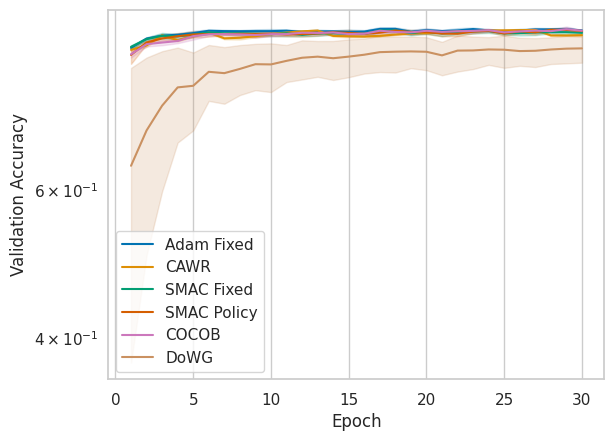

In [6]:

cocob_va = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
adam_fixed_va = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_fixed_va = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
cawr_va = toChunkedDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, 1)
smac_policy_va = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dowg_va = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)

sns.lineplot(data=adam_fixed_va, x='epoch', y='value', label='Adam Fixed')
sns.lineplot(data=cawr_va, x='epoch', y='value', label='CAWR')
sns.lineplot(data=smac_fixed_va, x='epoch', y='value', label='SMAC Fixed')
sns.lineplot(data=smac_policy_va, x='epoch', y='value', label='SMAC Policy')
sns.lineplot(data=cocob_va, x='epoch', y='value', label='COCOB')
sns.lineplot(data=dowg_va, x='epoch', y='value', label='DoWG')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.yscale('log')

Text(0, 0.5, 'Validation Accuracy')

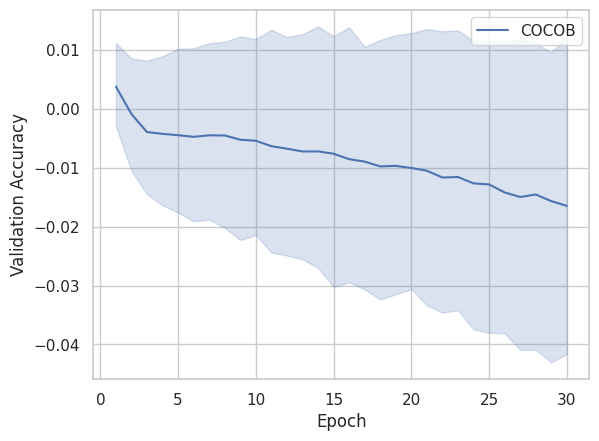

In [10]:

cocob_elr = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'effective_lrs', 9)
sns.lineplot(data=cocob_elr, x='epoch', y='value', label='COCOB')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')